In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv('../../data/busan_youth_v4.csv', index_col='Unnamed: 0')
# merged = pd.read_cs/v('../../../data/busan_youth_v4.csv', index_col='Unnamed: 0')
df.head()

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),기업밀도,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)
0,2016,강원특별자치도,1536.2750,22.40,0.0,3023906.0,1444.0,0.012368,13.734520,351.305988,44677.444,1.149646,-2.070627
1,2016,경기도,12509.4835,61.61,0.0,3328379.0,3925.0,0.006235,4.028943,2230.077238,433443.961,1.820153,-0.773010
2,2016,경상남도,3348.2515,36.61,0.0,3257296.0,1689.0,0.007168,5.764203,652.882347,113497.638,-0.054546,-2.108272
3,2016,경상북도,2683.4775,26.10,0.0,3326347.0,1035.0,0.014533,7.266690,549.557763,112216.094,-0.105801,-2.177146
4,2016,광주광역시,1461.5310,46.68,0.0,2994355.0,1284.0,0.012316,3.900020,289.682121,39427.386,-0.390397,-3.492136


In [3]:
# 변수 분류
# 종속변수
y_cols = df[['청년_19_29_증감률(%)', '청년_30_39_증감률(%)']]

# 독립변수
x_cols = df[['상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도']]

# 독립변수(통계방식변경)
x_cols_control = df[['상용월평균급여(원)', '문화예술활동(건)', 
                '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도', '통계방식변경']]


# 통제변수
meta_cols = df[['연앙인구수(천명)', '재정자립도(%)', '지역내총생산(십억원)']]

# Group by
group_cols = df[['연도', '행정구역']]

In [4]:
df.columns

Index(['연도', '행정구역', '연앙인구수(천명)', '재정자립도(%)', '통계방식변경', '상용월평균급여(원)',
       '문화예술활동(건)', '대학수(천명당)', '문화기반시설수(십만명당)', '기업밀도', '지역내총생산(십억원)',
       '청년_19_29_증감률(%)', '청년_30_39_증감률(%)'],
      dtype='object')

In [5]:
df.head()

,연도,행정구역,연앙인구수(천명),재정자립도(%),통계방식변경,상용월평균급여(원),문화예술활동(건),대학수(천명당),문화기반시설수(십만명당),기업밀도,지역내총생산(십억원),청년_19_29_증감률(%),청년_30_39_증감률(%)
0,2016,강원특별자치도,1536.2750,22.40,0.0,3023906.0,1444.0,0.012368,13.734520,351.305988,44677.444,1.149646,-2.070627
1,2016,경기도,12509.4835,61.61,0.0,3328379.0,3925.0,0.006235,4.028943,2230.077238,433443.961,1.820153,-0.773010
2,2016,경상남도,3348.2515,36.61,0.0,3257296.0,1689.0,0.007168,5.764203,652.882347,113497.638,-0.054546,-2.108272
3,2016,경상북도,2683.4775,26.10,0.0,3326347.0,1035.0,0.014533,7.266690,549.557763,112216.094,-0.105801,-2.177146
4,2016,광주광역시,1461.5310,46.68,0.0,2994355.0,1284.0,0.012316,3.900020,289.682121,39427.386,-0.390397,-3.492136


In [23]:
import pandas as pd
import statsmodels.api as sm

# ===============================
# 0) 너가 이미 만든 분류를 "컬럼명 리스트"로 변환
# ===============================
y19 = '청년_19_29_증감률(%)'
y30 = '청년_30_39_증감률(%)'

# 체급(구조) 통제변수 = meta_cols
meta_list = meta_cols.columns.tolist()          # ['연앙인구수(천명)', '재정자립도(%)', '지역내총생산(십억원)']
group_list = group_cols.columns.tolist()        # ['연도', '행정구역']

# ===============================
# 1) 체급 대비 이탈도(gap) 계산 함수 (안 깨지는 버전)
# ===============================
def make_gap_by_structure(df, y_col, x_list, group_list=None):
    """
    y_col: 종속변수 컬럼명(문자열)
    x_list: 체급 변수 컬럼명 리스트
    group_list: (선택) 함께 들고갈 그룹 컬럼명 리스트
    """
    # 1) 필요한 컬럼만 복사
    need = [y_col] + x_list + (group_list if group_list else [])
    tmp = df[need].copy()

    # 2) 숫자형 변환 (문자 섞임 방지)
    for c in [y_col] + x_list:
        tmp[c] = pd.to_numeric(tmp[c], errors='coerce')

    # 3) 결측 제거
    tmp = tmp.dropna(subset=[y_col] + x_list)

    # 4) 표본수 체크 (회귀 불가 방지)
    #    파라미터 수 = 체급변수 개수 + 상수항(1)
    k = len(x_list) + 1
    if len(tmp) <= k:
        raise ValueError(
            f"[{y_col}] 유효행 {len(tmp)}개라 회귀 불가 (필요: {k+1}개 이상). "
            f"-> meta_cols/종속변수 결측 또는 merge 문제 가능"
        )

    # 5) OLS 적합
    X = sm.add_constant(tmp[x_list])
    y = tmp[y_col]
    model = sm.OLS(y, X).fit()

    # 6) 예측값/갭 (index 유지해서 Series로 생성)
    y_hat = pd.Series(model.predict(X), index=tmp.index, name=f"{y_col}_hat")
    gap = (y - y_hat).rename(f"gap_{y_col}")    # 실제 - 기대

    # 7) 원본 df 길이에 맞게 되돌리기(없는 행은 NaN)
    gap_full = gap.reindex(df.index)
    y_hat_full = y_hat.reindex(df.index)

    return gap_full, y_hat_full, model


# ===============================
# 2) 19-29, 30-39 각각 계산
# ===============================
df[f'{y19}_hat'] = pd.NA
df[f'{y30}_hat'] = pd.NA

df[f'gap_19'], df[f'{y19}_hat'], model19 = make_gap_by_structure(df, y19, meta_list, group_list)
df[f'gap_30'], df[f'{y30}_hat'], model30 = make_gap_by_structure(df, y30, meta_list, group_list)

print("=== 19-29 모델 ===")
print(f"R2={model19.rsquared:.4f}, AdjR2={model19.rsquared_adj:.4f}")

print("=== 30-39 모델 ===")
print(f"R2={model30.rsquared:.4f}, AdjR2={model30.rsquared_adj:.4f}")


# ===============================
# 3) 부산/대전 빠른 비교 (최신연도 기준)
# ===============================
latest_year = int(df['연도'].min())

cmp = (
    df[df['연도'] == latest_year]
    .loc[:, ['행정구역', '연도', y19, y30, f'{y19}_hat', f'{y30}_hat', 'gap_19', 'gap_30']]
    .sort_values('gap_19')  # gap이 더 음수일수록 "체급 대비 더 많이 이탈"
)

print("\n=== 최신연도 gap_19 하위(이탈 큰 순) 10개 ===")
print(cmp.head(100))

print("\n=== 부산/대전 최신연도 비교 ===")
print(cmp[cmp['행정구역'].isin(['부산광역시', '대전광역시'])])


=== 19-29 모델 ===
R2=0.0770, AdjR2=0.0585
=== 30-39 모델 ===
R2=0.0724, AdjR2=0.0537

=== 최신연도 gap_19 하위(이탈 큰 순) 10개 ===
       행정구역    연도  청년_19_29_증감률(%)  청년_30_39_증감률(%)  청년_19_29_증감률(%)_hat  \
7     부산광역시  2016        -1.153083        -1.827051             0.050451   
8     서울특별시  2016        -0.900674        -2.863040             0.058865   
5     대구광역시  2016        -0.380253        -2.570359             0.032024   
4     광주광역시  2016        -0.390397        -3.492136            -0.496030   
11    인천광역시  2016         0.568585        -1.069818             0.462053   
10    울산광역시  2016         0.001248        -1.474983            -0.442453   
6     대전광역시  2016         0.640018        -2.415547            -0.276069   
2      경상남도  2016        -0.054546        -2.108272            -1.224487   
1       경기도  2016         1.820153        -0.773010             0.187001   
3      경상북도  2016        -0.105801        -2.177146            -2.220812   
13  전북특별자치도  2016         0.410164        -2.7

In [24]:
model19.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        청년_19_29_증감률(%)   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     4.146
Date:                Fri, 30 Jan 2026   Prob (F-statistic):            0.00744
Time:                        14:20:10   Log-Likelihood:                -393.64
No. Observations:                 153   AIC:                             795.3
Df Residuals:                     149   BIC:                             807.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.3757      0.788     -4.285      0.000      -4.932      -1.819
연앙인구수(천명)       0.0006      0.000      1.889      0.061    -2.9e-05       0.001
재정자립도(%)        0.0573      0.021      2.788      0.006       0.017       0.098
지역내총생산(십억원) -1.805e-05   7.34e-06     -2.460      0.015   -3.25e-05   -3.55e-06
==============================================================================
Omnibus:                      106.192   Durbin-Watson:                   1.486
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1179.004
Skew:                           2.307   Prob(JB):                    9.61e-257
Kurtosis:                      15.793   Cond. No.                     5.88e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.88e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

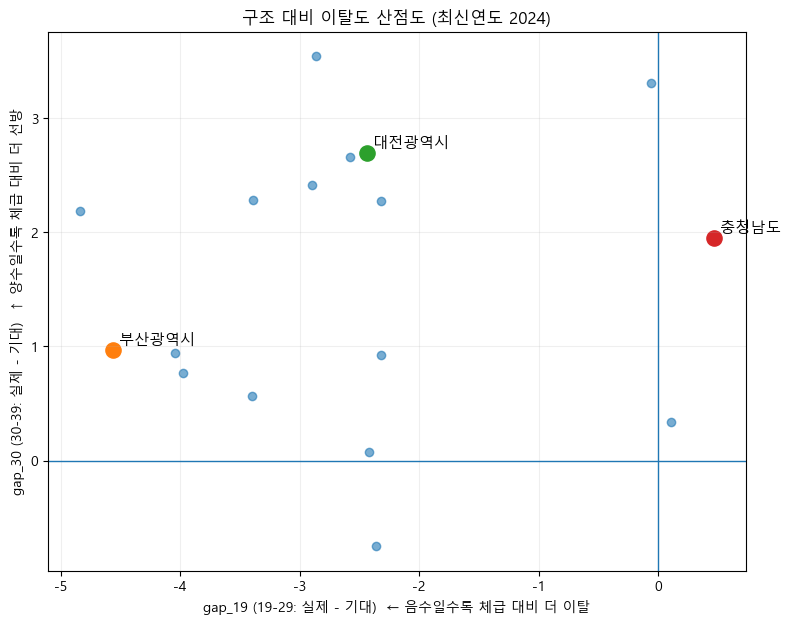

In [20]:
import matplotlib.pyplot as plt

# -------------------------------
# 1) 최신연도만 필터 (너 출력 기준 2024)
# -------------------------------
latest_year = int(df["연도"].max())
d = df[df["연도"] == latest_year].copy()

# -------------------------------
# 2) 산점도 그릴 컬럼 준비
#    - x: gap_19 (19-29 체급 대비 이탈도)
#    - y: gap_30 (30-39 체급 대비 이탈도)
# -------------------------------
x = d["gap_19"]
y = d["gap_30"]

# 결측 제거 (산점도 오류 방지)
mask = x.notna() & y.notna()
d = d[mask].copy()
x = d["gap_19"]
y = d["gap_30"]

# -------------------------------
# 3) 기본 산점도(전체 도시)
# -------------------------------
plt.figure(figsize=(9, 7))
plt.scatter(x, y, alpha=0.6)

# 기준선(0,0) 넣기: 구조 대비 선방/이탈 사분면 해석이 쉬워짐
plt.axvline(0, linewidth=1)
plt.axhline(0, linewidth=1)

# -------------------------------
# 4) 특정 도시 강조 + 라벨 표시
# -------------------------------
targets = ["부산광역시", "대전광역시", "충청남도"]  # 필요하면 추가/수정

for t in targets:
    sub = d[d["행정구역"] == t]
    if sub.empty:
        print(f"[주의] 최신연도({latest_year})에 '{t}' 데이터가 없어서 표시 못함.")
        continue

    # 도시가 1개 행이라고 가정(연도별 1행)
    tx = float(sub["gap_19"].iloc[0])
    ty = float(sub["gap_30"].iloc[0])

    # 강조점 다시 찍기 (더 진하게 보이도록)
    plt.scatter([tx], [ty], s=120)

    # 라벨(겹침 방지로 약간 오프셋)
    plt.text(tx + 0.05, ty + 0.05, t, fontsize=11)

# -------------------------------
# 5) 제목/축 라벨
# -------------------------------
plt.title(f"구조 대비 이탈도 산점도 (최신연도 {latest_year})")
plt.xlabel("gap_19 (19-29: 실제 - 기대)  ← 음수일수록 체급 대비 더 이탈")
plt.ylabel("gap_30 (30-39: 실제 - 기대)  ↑ 양수일수록 체급 대비 더 선방")
plt.grid(True, alpha=0.2)

plt.show()
